In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import os
from hdpgpc.get_data import compute_estimators_LDS
import math
from scipy.fft import fft
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import importlib
import pickle
import hdpgpc.GPI_HDP as hdpgp
import re
from datetime import datetime, timedelta
import time

In [3]:
from hdpgpc.util_plots import print_results
import hdpgpc.util_plots as up
importlib.reload(up)

<module 'hdpgpc.util_plots' from 'C:\\Users\\marco\\OneDrive - Universidade de Santiago de Compostela (1)\\CITIUS\\HDP-GPC\\hdpgpc\\hdpgpc\\util_plots.py'>

---

### 1. Lectura de datos

In [26]:
cwd = os.path.dirname(os.getcwd())
data_path = os.path.join(cwd, 'data')
data = np.load(os.path.join(data_path, 'VES3.npy'))
freq = np.load(os.path.join(data_path, 'freq.npy'))

print("Shape of the data: ")
print(data.shape)
num_samples, num_obs_per_sample, num_outputs = data.shape

Shape of the data: 
(14376, 171, 1)


### Se cogen solo los datos de un año natural

In [27]:
# Fechas de inicio y finalización
start_date = datetime(2019, 6, 25)
end_date = datetime(2021, 2, 12)

# Lista para guardar las fechas en formato cadena
dates = []

# Generar fechas y horas
current_date = start_date
while current_date <= end_date:
    for hour in range(24):  # 24 horas por día
        formatted_date = current_date.replace(hour=hour).strftime("%Y-%m-%d")
        dates.append(formatted_date)
    current_date += timedelta(days=1)

data_2 = data.reshape(num_samples, num_obs_per_sample)
data_2 = pd.DataFrame(data_2)
data_2['fecha'] = dates

data_2['fecha'] = pd.to_datetime(data_2['fecha'])

data = data_2[data_2['fecha'].dt.year == 2020]
data = data.drop(columns='fecha')
data = data.to_numpy()
data = data[:, :, np.newaxis]

In [28]:
print("Shape of the data: ")
print(data.shape)
num_samples, num_obs_per_sample, num_outputs = data.shape

Shape of the data: 
(8784, 171, 1)


In [35]:
total_columns = data.shape[1]  # Número total de columnas
num_subset = 50  # Número de columnas a seleccionar

# Crear un subconjunto desde la primera hasta la última columna, seleccionando 50 de ellas
df_subset = data[:, ::(total_columns // num_subset), ::][:, :num_subset, ::]

In [41]:
total_columns = freq.shape[0]
num_subset = 50

# Seleccionar 50 columnas equidistantes
indices = np.linspace(0, total_columns - 1, num_subset, dtype=int)
fsubset = freq[indices]

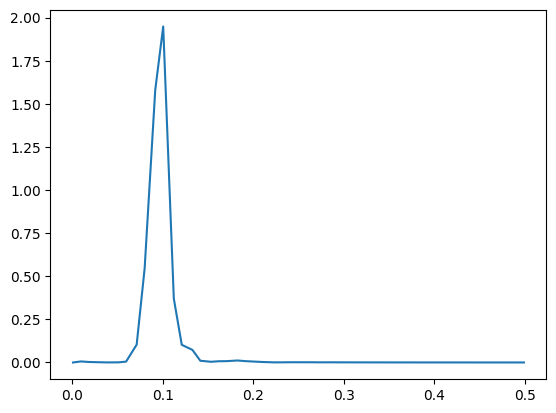

In [46]:
plt.plot(fsubset, df_subset[0, : , 0])

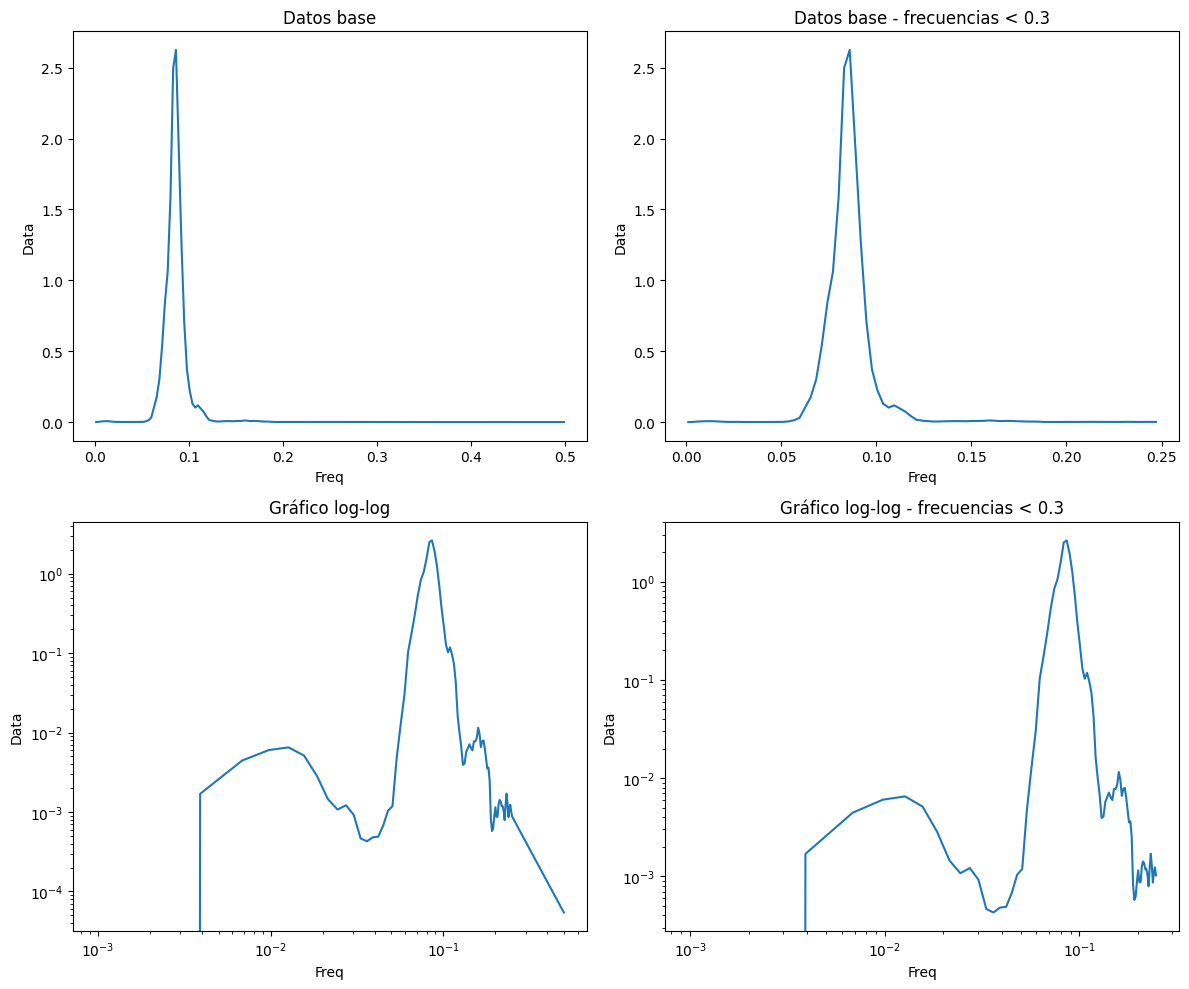

In [47]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Gráfica 1
axs[0, 0].plot(freq, data[0, :, 0])
axs[0, 0].set_title("Datos base")
axs[0, 0].set_xlabel("Freq")
axs[0, 0].set_ylabel("Data")

# Gráfica 2
axs[0, 1].plot(freq[:85], data[0, :85, 0])
axs[0, 1].set_title("Datos base - frecuencias < 0.3")
axs[0, 1].set_xlabel("Freq")
axs[0, 1].set_ylabel("Data")

# Gráfica 3
axs[1, 0].loglog(freq, data[0, :, 0])
axs[1, 0].set_title("Gráfico log-log")
axs[1, 0].set_xlabel("Freq")
axs[1, 0].set_ylabel("Data")

# Gráfica 4
axs[1, 1].loglog(freq[:85], data[0, :85, 0])
axs[1, 1].set_title("Gráfico log-log - frecuencias < 0.3")
axs[1, 1].set_xlabel("Freq")
axs[1, 1].set_ylabel("Data")

# Ajustar el layout para evitar superposición
plt.tight_layout()
plt.show()

In [20]:
std, std_dif, bound_sigma, bound_gamma = compute_estimators_LDS(data, n_f=50)
#Seem like these estimators are so big for this data, let's reduce them
std = std * 0.5
std_dif = std_dif * 1.0
bound_sigma = (std * 1e-7, std * 1e-6)
bound_gamma = (std_dif * 1e-9, std_dif * 1e-8)

print("Final sigma:", std)
print("Final gamma:", std_dif)
print("Final sigma bound:", bound_sigma)
print("Final gamma bound:", bound_gamma)

Sigma estimated: 0.008764265286646068
Gamma estimated: 0.008764265286646068
Final sigma: 0.004382132643323034
Final gamma: 0.008764265286646068
Final sigma bound: (4.3821326433230337e-10, 4.382132643323034e-09)
Final gamma bound: (8.76426528664607e-12, 8.764265286646068e-11)


In [21]:
M = 2
sigma = [std * 1.0] * M
gamma = [std_dif * 1.0] * M

In [22]:
outputscale_ = 0.1
ini_lengthscale = 1e-3
bound_lengthscale = (1e-7, 5e-3)

In [23]:
samples = [0, num_obs_per_sample]
l, L = samples[0], samples[1]
# x_basis has to have the same dimension structure as data[0], in this case (171,1) but it could be (n_inducing_points, 1).
x_basis = np.atleast_2d(freq[:85]).T
x_train = np.atleast_2d(freq[:85]).T
print(x_train.shape)
#If x_basis is wanted to be smaller than the observations length, then the inducing points approach can be applied setting this parameter to True.
inducing_points = False

(85, 1)


In [24]:
#Choose if warp is going to be applied. (In the most recent version is optimized to work with online inference, but it can be used in offline as an additional step at the end of the clustering).
warp = False
#Warp priors
noise_warp = std * 0.1
bound_noise_warp = (noise_warp * 0.1, noise_warp * 0.2)
#Warp time indexes
x_basis_warp = np.atleast_2d(np.arange(freq[0], freq[-1], freq.shape[0]/2.0, dtype=np.float64)).T

In [25]:
sw_gp = hdpgp.GPI_HDP(x_basis=x_basis, x_basis_warp=x_basis_warp, n_outputs=1,
                          ini_lengthscale=ini_lengthscale, bound_lengthscale=bound_lengthscale,
                          ini_gamma=gamma, ini_sigma=sigma, ini_outputscale=outputscale_, noise_warp=noise_warp,
                          bound_sigma=bound_sigma, bound_gamma=bound_gamma, bound_noise_warp=bound_noise_warp,
                          verbose=True, max_models=100, inducing_points=inducing_points, estimation_limit=30)

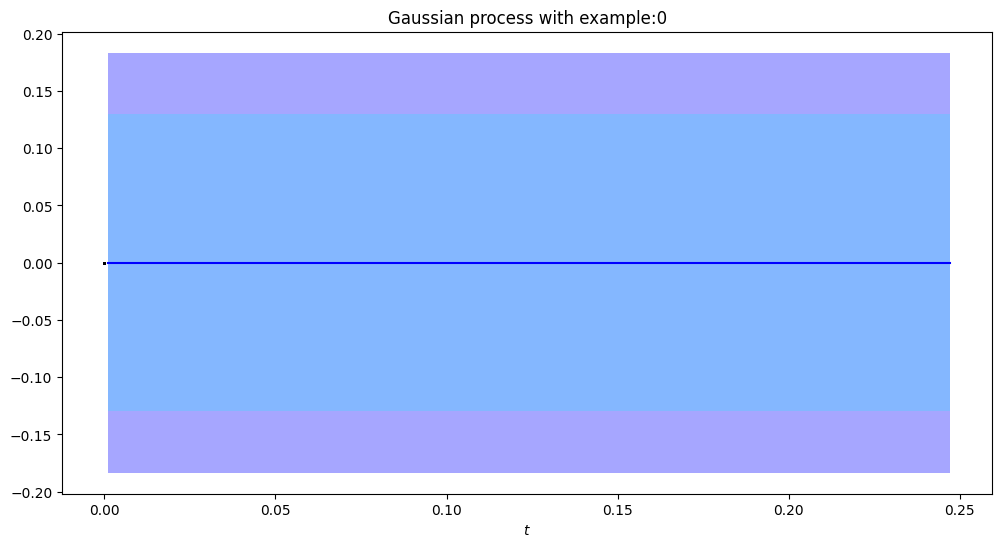

In [26]:
sw_gp.gpmodels[0][0].plot_last(0)

In [27]:
sw_gp = hdpgp.GPI_HDP(x_basis=x_basis, x_basis_warp=x_basis_warp, n_outputs=1,
                          ini_lengthscale=ini_lengthscale, bound_lengthscale=bound_lengthscale,
                          ini_gamma=gamma, ini_sigma=sigma, ini_outputscale=outputscale_, noise_warp=noise_warp,
                          bound_sigma=bound_sigma, bound_gamma=bound_gamma, bound_noise_warp=bound_noise_warp,
                          verbose=False, max_models=100, inducing_points=inducing_points, reestimate_initial_params=False,
                          n_explore_steps=15, free_deg_MNIV=3)

num_samples = data.shape[0]
x_trains = np.array([x_train] * num_samples)
sw_gp.include_batch(x_trains, data[:,:85,[0]])

Group responsability estimated: [8784    0]

 Fitting_GP: 

Iter 1/4000 - Loss: 39903033.028
Iter 501/4000 - Loss: 73.640
Iter 1001/4000 - Loss: 17.968
Iter 1501/4000 - Loss: 7.649
Iter 2001/4000 - Loss: 4.051
Iter 2501/4000 - Loss: 2.357
Iter 3001/4000 - Loss: 1.421
Iter 3501/4000 - Loss: 0.852


Parameter name: likelihood.noise_covar.raw_noise           value = [2.58452212]
Parameter name: mean_module.raw_constant                   value = 0.1576189914281837
Parameter name: covar_module.raw_outputscale               value = 3.269161735058965
Parameter name: covar_module.base_kernel.raw_lengthscale   value = [[-5.13453025]]
---Kernel estimated---
1.82**2 * RBF(length_scale=0.00587) + WhiteKernel(noise_level=4.11e-09)

-----------Lead 1-----------
Step 1/15- Trying to divide: 0 with beat 7973
Sum resp_temp: tensor([8769.,   15.])
Q_bas: tensor(-428042.5972), Q_lat: tensor(-948488.5173), Elbo_bas: tensor([-951304.1355])
Q_bas_post: tensor(-421381.0317), Q_lat: tensor(-934168.2679), Elbo

Sum resp_temp: tensor([8.6100e+03, 9.2000e+01, 6.5000e+01, 1.0000e+01, 7.0000e+00, 0.0000e+00])
Q_bas: tensor(-414020.7306), Q_lat: tensor(-770464.6648), Elbo_bas: tensor([-774587.3278])
Q_bas_post: tensor(-412977.6568), Q_lat: tensor(-762512.6455), Elbo_post: tensor([-766684.8022])
Reallocating beats into existing groups.
First resp: tensor([8.6100e+03, 9.2000e+01, 6.5000e+01, 1.0000e+01, 7.0000e+00, 0.0000e+00])
Mean_sq: tensor(-412977.6568)
ELBO: tensor([-1179662.4591])

-------Lower Bound Iteration 7-------
Group responsability estimated: [8610   92   65   10    7    0]

-----------Lead 1-----------

-----------Lead 1-----------

   -----------Model 1-----------

   -----------Model 2-----------

   -----------Model 3-----------

   -----------Model 4-----------

   -----------Model 5-----------

   -----------Model 6-----------
Sum resp_temp: tensor([8.6100e+03, 9.2000e+01, 6.5000e+01, 1.0000e+01, 7.0000e+00, 0.0000e+00])
Q_bas: tensor(-412977.6568), Q_lat: tensor(-762512.6455), E

ELBO_reduction: 0.0
Mean_sq: tensor(-408705.3672)
ELBO: tensor([-1086894.1248])

-------Lower Bound Iteration 11-------
Group responsability estimated: [8582   82   52   29   16    9    6    6    2]

-----------Lead 1-----------

-----------Lead 1-----------

   -----------Model 1-----------

   -----------Model 2-----------

   -----------Model 3-----------

   -----------Model 4-----------

   -----------Model 5-----------

   -----------Model 6-----------

   -----------Model 7-----------

   -----------Model 8-----------

   -----------Model 9-----------

   -----------Model 10-----------
Sum resp_temp: tensor([8.5160e+03, 9.6000e+01, 8.1000e+01, 5.2000e+01, 1.6000e+01, 9.0000e+00,
        6.0000e+00, 6.0000e+00, 2.0000e+00, 0.0000e+00])
Q_bas: tensor(-408705.3672), Q_lat: tensor(-673337.3023), Elbo_bas: tensor([-678201.8923])
Q_bas_post: tensor(-404113.7438), Q_lat: tensor(-636204.9937), Elbo_post: tensor([-639366.5544])
Reallocating beats into existing groups.
First resp: tensor(

Sum resp_temp: tensor([8.4950e+03, 9.6000e+01, 8.1000e+01, 5.0000e+01, 2.1000e+01, 1.5000e+01,
        9.0000e+00, 6.0000e+00, 4.0000e+00, 4.0000e+00, 2.0000e+00, 1.0000e+00])
Q_bas: tensor(-402929.1525), Q_lat: tensor(-607275.1853), Elbo_bas: tensor([-608275.4698])
Q_bas_post: tensor(-402897.6732), Q_lat: tensor(-615578.1834), Elbo_post: tensor([-620688.8820])
Possibly better q_obs but worse elbo.
Step 3/15- Trying to divide: 5 with beat 8648
Sum resp_temp: tensor([8.4950e+03, 9.6000e+01, 8.1000e+01, 5.2000e+01, 2.1000e+01, 1.3000e+01,
        9.0000e+00, 5.0000e+00, 4.0000e+00, 4.0000e+00, 2.0000e+00, 2.0000e+00])
Q_bas: tensor(-402929.1525), Q_lat: tensor(-607275.1853), Elbo_bas: tensor([-608275.4698])
Q_bas_post: tensor(-402921.6753), Q_lat: tensor(-611629.1617), Elbo_post: tensor([-614821.1903])
Possibly better q_obs but worse elbo.
Step 4/15- Trying to divide: 7 with beat 7977
Sum resp_temp: tensor([8.4950e+03, 9.6000e+01, 8.1000e+01, 5.2000e+01, 2.1000e+01, 1.6000e+01,
        9

Current resp: tensor([7.0339e+03, 1.4670e+03, 9.1000e+01, 8.1000e+01, 5.2000e+01, 2.1000e+01,
        1.6000e+01, 9.0000e+00, 5.0000e+00, 4.0000e+00, 2.0000e+00, 2.0000e+00,
        1.0000e+00])
ELBO_reduction: 0.0
Mean_sq: tensor(-400507.5031)
ELBO: tensor([-927123.4205])

-------Lower Bound Iteration 17-------
Group responsability estimated: [7033 1467   91   81   52   21   16    9    5    4    2    2    1]

-----------Lead 1-----------

-----------Lead 1-----------

   -----------Model 1-----------

   -----------Model 2-----------

   -----------Model 3-----------

   -----------Model 4-----------

   -----------Model 5-----------

   -----------Model 6-----------

   -----------Model 7-----------

   -----------Model 8-----------

   -----------Model 9-----------

   -----------Model 10-----------

   -----------Model 11-----------

   -----------Model 12-----------

   -----------Model 13-----------

   -----------Model 14-----------
Sum resp_temp: tensor([8.4950e+03, 9.6000e+01,

Mean_sq: tensor(-400507.5031)
ELBO: tensor([-927157.8462])

-------Lower Bound Iteration 18-------
Group responsability estimated: [7033 1467   91   81   52   21   16    9    5    4    2    2    1    0]

-----------Lead 1-----------

-----------Lead 1-----------

   -----------Model 1-----------

   -----------Model 2-----------

   -----------Model 3-----------

   -----------Model 4-----------

   -----------Model 5-----------

   -----------Model 6-----------

   -----------Model 7-----------

   -----------Model 8-----------

   -----------Model 9-----------

   -----------Model 10-----------

   -----------Model 11-----------

   -----------Model 12-----------

   -----------Model 13-----------

   -----------Model 14-----------
Sum resp_temp: tensor([8.4950e+03, 9.6000e+01, 8.1000e+01, 5.2000e+01, 2.1000e+01, 1.6000e+01,
        9.0000e+00, 5.0000e+00, 4.0000e+00, 2.0000e+00, 2.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00])
Q_bas: tensor(-400507.5031), Q_lat: tensor(-5191

KeyboardInterrupt: 

In [95]:
from hdpgpc.util_plots import print_results
import hdpgpc.util_plots as up
importlib.reload(up)

<module 'hdpgpc.util_plots' from 'C:\\Users\\marco\\OneDrive - Universidade de Santiago de Compostela (1)\\CITIUS\\HDP-GPC\\hdpgpc\\hdpgpc\\util_plots.py'>

Model 1 : MainModel: N : [N-7976]
Model 2 : MainModel: N : [N-650]
Model 3 : MainModel: N : [N-130]
Model 4 : MainModel: N : [N-17]
Model 5 : MainModel: N : [N-11]
Model 6  : []
Model 7  : []
Classification error:  0.0 / 8784 -- 0.0


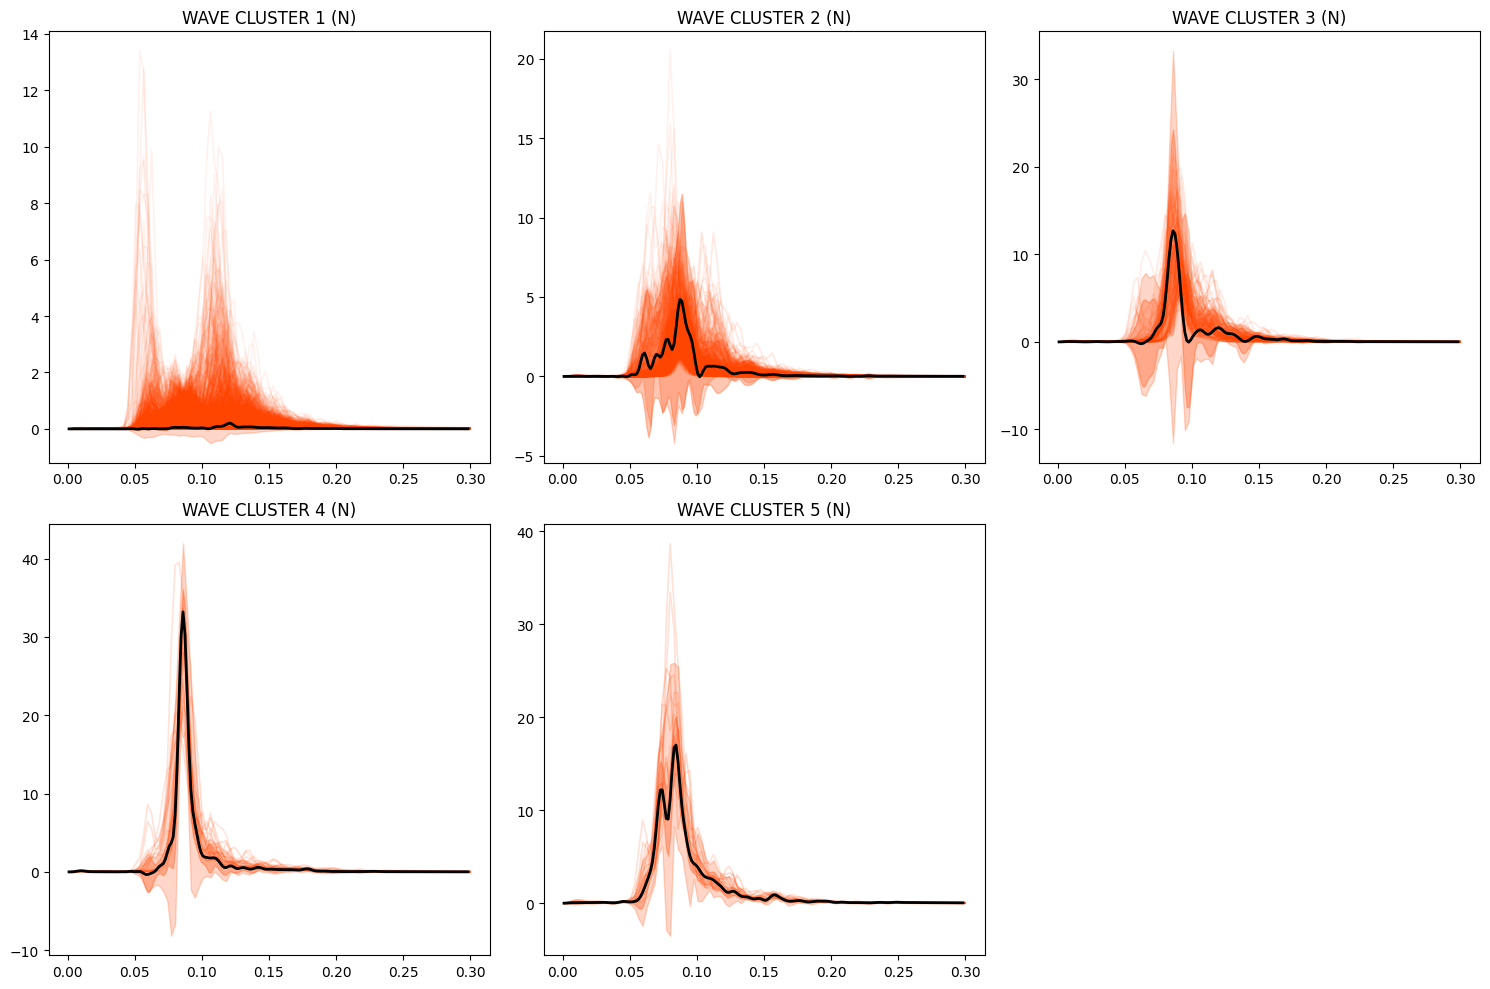

In [96]:
labels = np.array(['N'] * num_samples)
main_model = print_results(sw_gp, labels, 0, error=False)
selected_gpmodels = sw_gp.selected_gpmodels()
up.plot_models_plotly(sw_gp, selected_gpmodels, main_model, labels, N_0=0, lead=0, step=(freq[1]-freq[0])/2, 
                   plot_latent=True, title='WAVE CLUSTER',ticks=True)

---

# Gráfica distribución por meses y clusters

In [29]:
from datetime import datetime, timedelta

# Fechas de inicio y finalización
start_date = datetime(2019, 6, 25)
end_date = datetime(2021, 2, 12)

# Lista para guardar las fechas en formato cadena
dates = []

# Generar fechas y horas
current_date = start_date
while current_date <= end_date:
    for hour in range(24):  # 24 horas por día
        formatted_date = current_date.replace(hour=hour).strftime("%Y-%m-%d")
        dates.append(formatted_date)
    current_date += timedelta(days=1)

print(f"Total de elementos: {len(dates)}")

Total de elementos: 14376


In [35]:
data_2 = data.reshape(14376, 171)
data_2 = pd.DataFrame(data_2)
data_2['fecha'] = dates

In [9]:
with open('sw_gp.pkl', 'rb') as file:
    load_sw_gp = pickle.load(file)
    
labels = np.array(['N'] * data.shape[0])

In [22]:
num_clusters = len(load_sw_gp.selected_gpmodels())
filas_datos = []

for K in range(num_clusters):
    y_train = load_sw_gp.gpmodels[0][K].y_train
    M = len(y_train)  # Máximo valor de L para este K
    for L in range(M):
        tensor_values = y_train[L].numpy().flatten()  # Convierte el tensor a una lista plana
        row = list(tensor_values) + [K]  # Añade K al final de la fila
        filas_datos.append(row)

In [52]:
# Crea un dataframe
df = pd.DataFrame(filas_datos)

# Renombra las columnas
num_tensor_values = len(filas_datos[0]) - 1  # Número de valores en el tensor
df.columns = [i for i in range(num_tensor_values)] + ["cluster"]

In [57]:
key_columns = df.columns[:171]

# Realiza el join utilizando las columnas clave
result_df = pd.merge(data_2, df, on=key_columns.tolist(), how="inner")  # 'inner' para intersección, ajusta según necesidad

In [58]:
result_df

,0,1,2,3,4,5,6,7,8,9,...,163,164,165,166,167,168,169,170,fecha,cluster
0,0.0,0.000076,0.000092,0.000024,0.000020,0.000026,0.000026,0.000017,0.000018,0.000026,...,0.000025,0.000024,0.000024,0.000023,0.000023,0.000022,0.000022,0.000021,2019-06-25,0
1,0.0,0.000018,0.000031,0.000026,0.000028,0.000029,0.000021,0.000012,0.000010,0.000010,...,0.000029,0.000028,0.000027,0.000027,0.000026,0.000026,0.000025,0.000024,2019-06-25,0
2,0.0,0.000051,0.000066,0.000034,0.000049,0.000051,0.000033,0.000020,0.000015,0.000021,...,0.000023,0.000022,0.000022,0.000021,0.000021,0.000020,0.000020,0.000019,2019-06-25,0
3,0.0,0.000031,0.000057,0.000044,0.000035,0.000025,0.000019,0.000018,0.000016,0.000014,...,0.000056,0.000055,0.000054,0.000052,0.000051,0.000050,0.000049,0.000048,2019-06-25,0
4,0.0,0.000087,0.000146,0.000072,0.000048,0.000069,0.000050,0.000029,0.000037,0.000036,...,0.000015,0.000015,0.000015,0.000014,0.000014,0.000014,0.000013,0.000013,2019-06-25,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.000019,0.000038,0.000025,0.000011,0.000007,0.000005,0.000010,0.000016,0.000020,...,0.000011,0.000011,0.000011,0.000010,0.000010,0.000010,0.000010,0.000009,2019-08-05,1
996,0.0,0.000018,0.000033,0.000022,0.000014,0.000015,0.000018,0.000017,0.000008,0.000008,...,0.000020,0.000020,0.000019,0.000019,0.000018,0.000018,0.000017,0.000017,2019-08-05,1
997,0.0,0.000018,0.000027,0.000020,0.000022,0.000015,0.000007,0.000009,0.000015,0.000019,...,0.000008,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000006,2019-08-05,1
998,0.0,0.000023,0.000047,0.000053,0.000062,0.000047,0.000025,0.000027,0.000031,0.000025,...,0.000045,0.000044,0.000042,0.000041,0.000040,0.000040,0.000039,0.000038,2019-08-05,1


In [65]:
result_df['fecha'] = pd.to_datetime(result_df['fecha'])
result_df['mes'] = result_df['fecha'].dt.month
result_df['dia'] = result_df['fecha'].dt.dayofyear

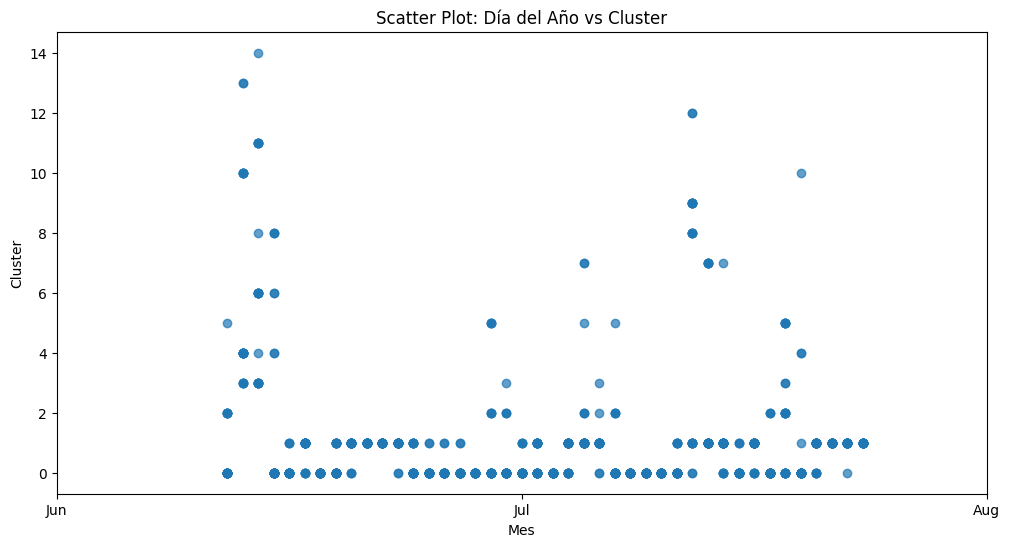

In [74]:
plt.figure(figsize=(12, 6))
plt.scatter(result_df['dia'], result_df['cluster'], alpha=0.7)



# Ajusta las etiquetas para que coincidan con los días del año
plt.title('Scatter Plot: Día del Año vs Cluster')
plt.xlabel('Mes')
plt.ylabel('Cluster')

# Agrega las etiquetas de los meses
plt.xticks(
    ticks=[15 + i * 30 for i in range(5, 8)],  # Aprox. posición para los meses
    labels=['Jun', 'Jul', 'Aug']
)

plt.show()

---

### Datos NDBC

In [1]:
df = pd.read_csv("../data/nbdc.txt ", delim_whitespace=True, header=0)
df = df.iloc[:, 5:]

NameError: name 'pd' is not defined

In [20]:
freq = df.columns
freq = freq.astype(float)

data = df.to_numpy()
data = data[:, :, np.newaxis]
data.shape

(8524, 47, 1)

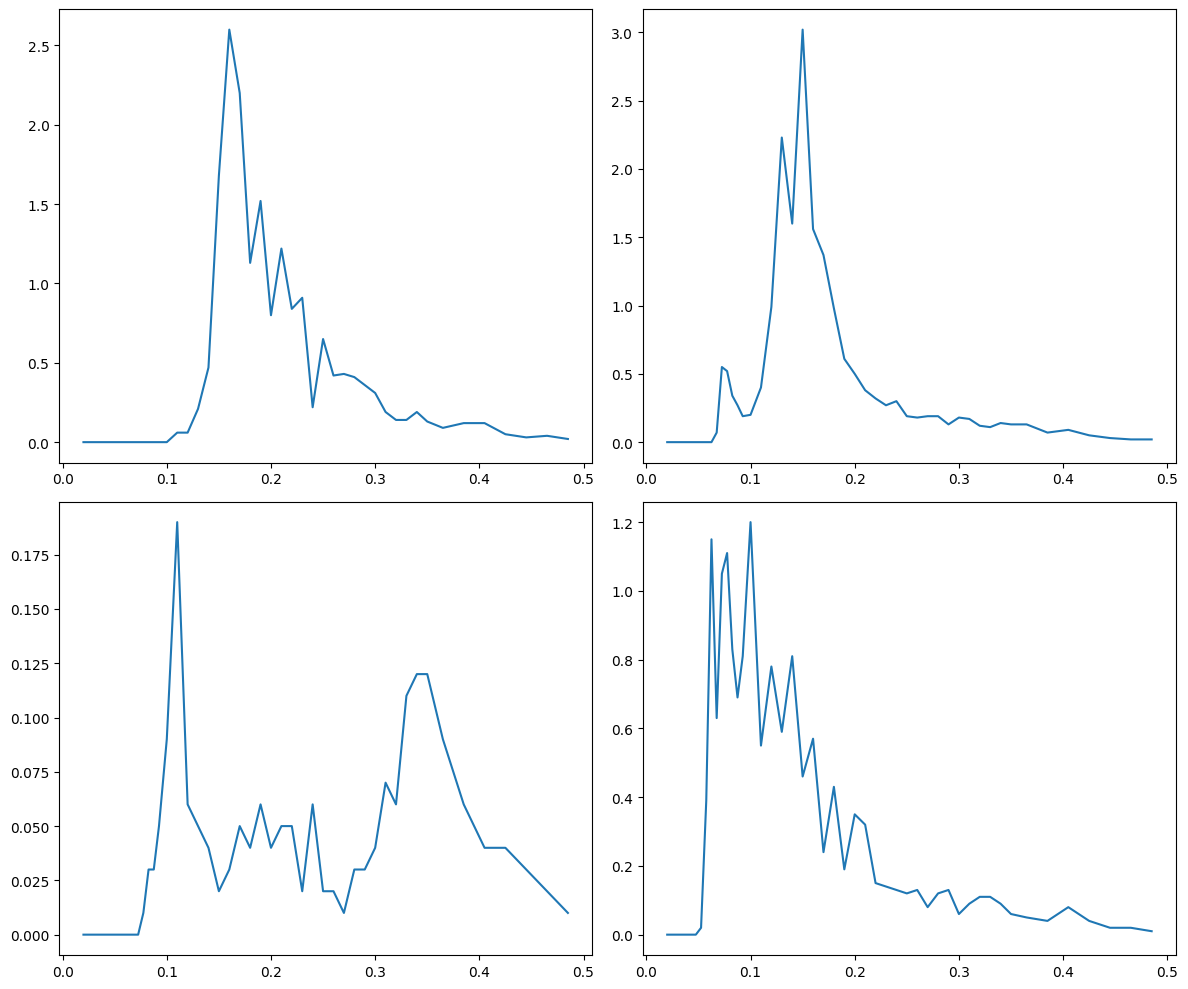

In [25]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Gráfica 1
axs[0, 0].plot(freq, data[0, :, 0])

# Gráfica 2
axs[0, 1].plot(freq, data[127, :, 0])

# Gráfica 3
axs[1, 0].plot(freq, data[35, :, 0])

# Gráfica 4
axs[1, 1].plot(freq, data[5923, :, 0])

# Ajustar el layout para evitar superposición
plt.tight_layout()
plt.show()